In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [25]:
df = pd.read_csv("Dataset_ModellingLead.csv", on_bad_lines='skip')

df.head()

,Unnamed: 0,FL_DATE,DEP_HOUR,MKT_UNIQUE_CARRIER,MKT_CARRIER_FL_NUM,OP_UNIQUE_CARRIER,OP_CARRIER_FL_NUM,TAIL_NUM,ORIGIN,DEST,...,CLOUD_COVER,ACTIVE_WEATHER,WEATHER_SEVERITY,TEMP_DEW_DIFF,WIND_INTENSITY,VISIBILITY_CATEGORY,HUMIDITY_LEVEL,WIND_DIRECTION,TOTAL_CLOUD,CLOUD_COVER_ENCODED
0,12,2022-01-01,6,AA,1019,AA,1019,N764US,SJC,DFW,...,1.0,0.0,7.640,3.89,0.0,Moderate,High,North,1.0,1
1,17,2022-01-01,7,AA,1025,AA,1025,N572UW,TUS,DFW,...,4.0,1.0,11.704,1.72,8.0,Moderate,Very High,South,1.0,4
2,19,2022-01-01,8,AA,1032,AA,1032,N771AN,JFK,MIA,...,4.0,0.0,11.419,0.50,5.0,Moderate,Very High,East,1.0,4
3,20,2022-01-01,23,AA,1033,AA,1033,N770UW,CLT,IND,...,3.0,0.0,11.781,1.72,8.0,Moderate,Very High,South,2.0,3
4,26,2022-01-01,20,AA,1043,AA,1043,N8009T,CLT,CLE,...,4.0,0.0,12.949,5.00,16.0,Moderate,High,South,3.0,4


In [26]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(1619240, 49)


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1619240 entries, 0 to 1619239
Data columns (total 49 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   Unnamed: 0           1619240 non-null  int64  
 1   FL_DATE              1619240 non-null  object 
 2   DEP_HOUR             1619240 non-null  int64  
 3   MKT_UNIQUE_CARRIER   1619240 non-null  object 
 4   MKT_CARRIER_FL_NUM   1619240 non-null  int64  
 5   OP_UNIQUE_CARRIER    1619240 non-null  object 
 6   OP_CARRIER_FL_NUM    1619240 non-null  int64  
 7   TAIL_NUM             1619240 non-null  object 
 8   ORIGIN               1619240 non-null  object 
 9   DEST                 1619240 non-null  object 
 10  DEP_TIME             1619240 non-null  object 
 11  CRS_DEP_TIME         1619240 non-null  object 
 12  TAXI_OUT             1619240 non-null  int64  
 13  DEP_DELAY            1619240 non-null  int64  
 14  AIR_TIME             1619240 non-null  int64  
 15

In [28]:
missing = df.isnull().sum().sort_values(ascending=False)

print(missing[missing > 0])

HUMIDITY_LEVEL    44
dtype: int64


In [29]:
df.describe()

,Unnamed: 0,DEP_HOUR,MKT_CARRIER_FL_NUM,OP_CARRIER_FL_NUM,TAXI_OUT,DEP_DELAY,AIR_TIME,DISTANCE,CANCELLED,LATITUDE,...,LOW_LEVEL_CLOUD,MID_LEVEL_CLOUD,HIGH_LEVEL_CLOUD,CLOUD_COVER,ACTIVE_WEATHER,WEATHER_SEVERITY,TEMP_DEW_DIFF,WIND_INTENSITY,TOTAL_CLOUD,CLOUD_COVER_ENCODED
count,1.619240e+06,1.619240e+06,1.619240e+06,1.619240e+06,1.619240e+06,1.619240e+06,1.619240e+06,1.619240e+06,1.619240e+06,1.619240e+06,...,1.619240e+06,1.619240e+06,1.619240e+06,1.619240e+06,1.619240e+06,1.619240e+06,1.619240e+06,1.619240e+06,1.619240e+06,1.619240e+06
mean,3.546551e+06,1.242780e+01,2.479355e+03,2.479345e+03,1.635399e+01,1.080097e+01,1.087195e+02,8.010199e+02,3.177540e-02,3.644955e+01,...,4.199149e-01,3.716731e-01,3.377424e-01,1.872660e+00,2.490860e-02,8.365687e+00,8.197073e+00,6.014749e+00,1.129330e+00,1.872660e+00
std,1.942320e+06,5.251538e+00,1.711937e+03,1.711943e+03,8.959868e+00,5.026041e+01,7.104251e+01,5.975137e+02,2.478747e-01,5.968923e+00,...,4.935449e-01,4.832519e-01,4.729404e-01,1.422614e+00,1.792695e-01,2.260441e+00,6.431412e+00,3.781363e+00,8.391798e-01,1.422614e+00
min,1.200000e+01,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-6.700000e+01,0.000000e+00,3.100000e+01,0.000000e+00,-1.433000e+01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.710000e-01,-3.390000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.915740e+06,8.000000e+00,1.073000e+03,1.073000e+03,1.100000e+01,-5.000000e+00,5.800000e+01,3.690000e+02,0.000000e+00,3.289722e+01,...,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,7.009000e+00,3.440000e+00,4.000000e+00,1.000000e+00,1.000000e+00
50%,3.632441e+06,1.200000e+01,2.155000e+03,2.155000e+03,1.400000e+01,-2.000000e+00,9.100000e+01,6.410000e+02,0.000000e+00,3.647528e+01,...,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,8.642000e+00,6.560000e+00,6.000000e+00,1.000000e+00,2.000000e+00
75%,5.161546e+06,1.700000e+01,3.710000e+03,3.710000e+03,1.900000e+01,8.000000e+00,1.390000e+02,1.034000e+03,0.000000e+00,4.069250e+01,...,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,0.000000e+00,9.969000e+00,1.106000e+01,8.000000e+00,2.000000e+00,3.000000e+00
max,6.954629e+06,2.300000e+01,9.678000e+03,9.678000e+03,1.970000e+02,5.995000e+03,6.970000e+02,5.095000e+03,4.000000e+00,7.128472e+01,...,1.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00,2.000000e+00,1.672400e+01,5.950000e+01,1.900000e+01,3.000000e+00,4.000000e+00


In [30]:
print(df['ACTIVE_WEATHER'].value_counts())

ACTIVE_WEATHER
0.0    1585262
1.0      27623
2.0       6355
Name: count, dtype: int64


In [31]:
weather_cols = [
    'WIND_SPD',
    'VISIBILITY',
    'TEMPERATURE',
    'REL_HUMIDITY'
]

for col in weather_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_1406/1786158452.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [32]:
print("Average Delay:")
print(df['DEP_DELAY'].mean())

Average Delay:
10.80097267854055


In [33]:
print("Maximum Delay:")
print(df['DEP_DELAY'].max())

Maximum Delay:
5995


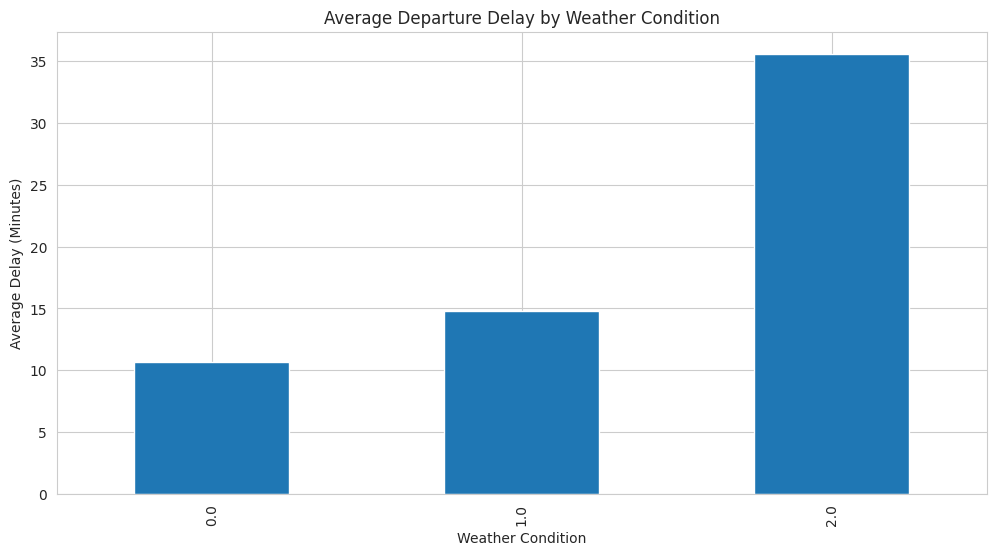

In [34]:
weather_delay = df.groupby('ACTIVE_WEATHER')['DEP_DELAY'].mean().sort_values()

plt.figure(figsize=(12,6))

weather_delay.plot(kind='bar')

plt.title("Average Departure Delay by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Delay (Minutes)")

plt.show()

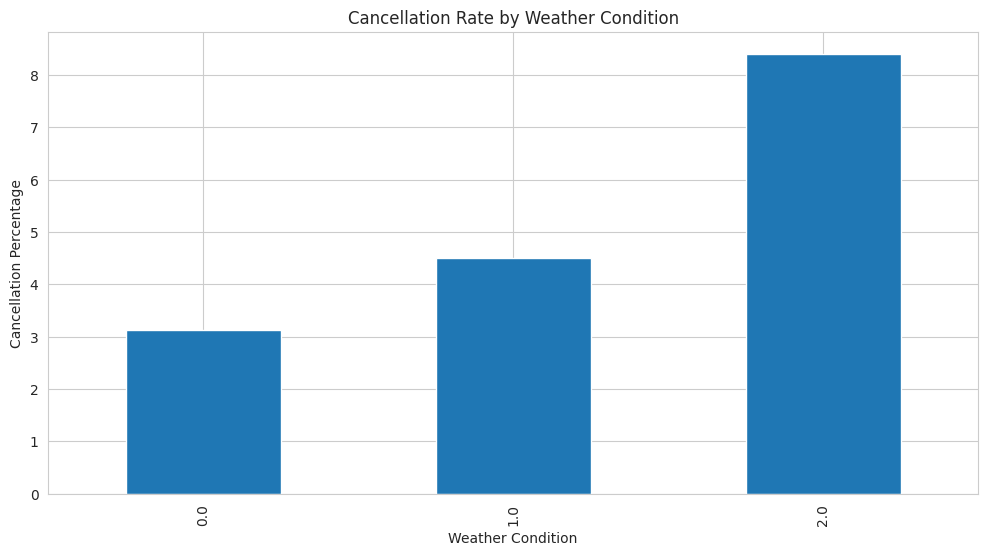

In [35]:
cancel_rate = df.groupby('ACTIVE_WEATHER')['CANCELLED'].mean()*100

plt.figure(figsize=(12,6))

cancel_rate.sort_values().plot(kind='bar')

plt.title("Cancellation Rate by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Cancellation Percentage")

plt.show()

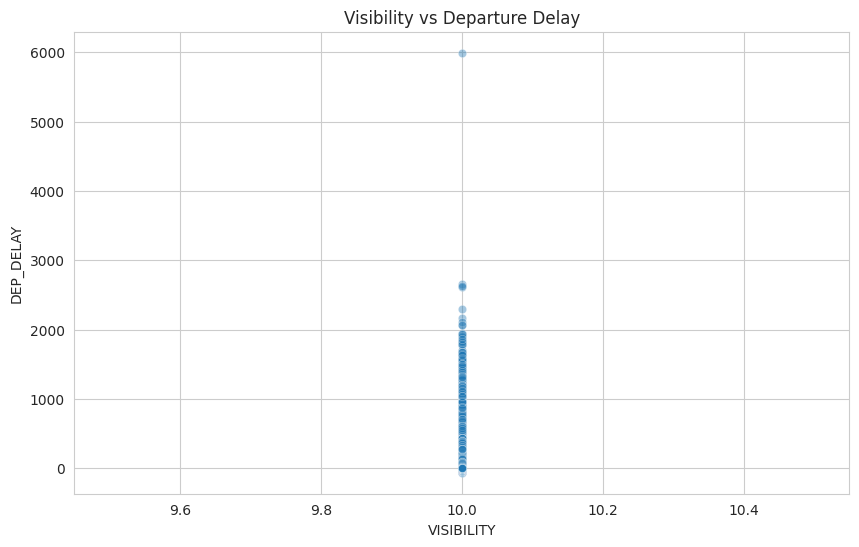

In [36]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='VISIBILITY',
    y='DEP_DELAY',
    data=df,
    alpha=0.4
)

plt.title("Visibility vs Departure Delay")

plt.show()

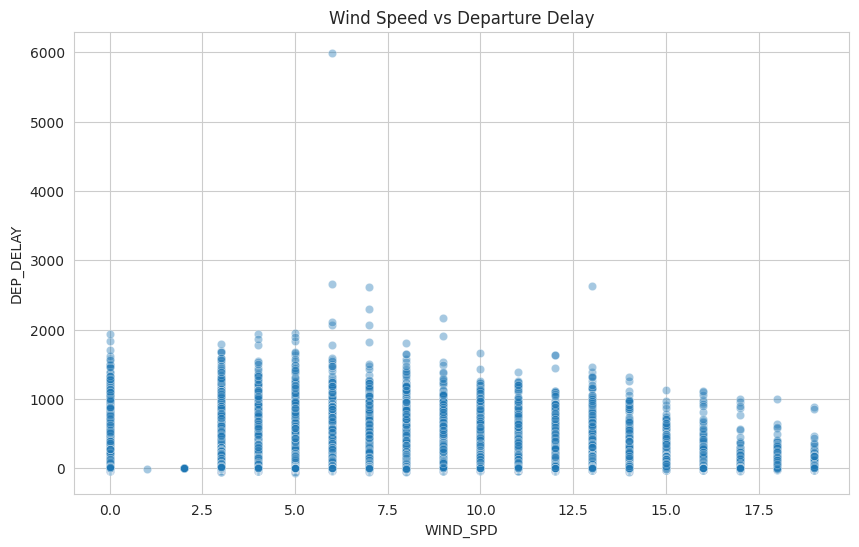

In [37]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='WIND_SPD',
    y='DEP_DELAY',
    data=df,
    alpha=0.4
)

plt.title("Wind Speed vs Departure Delay")

plt.show()

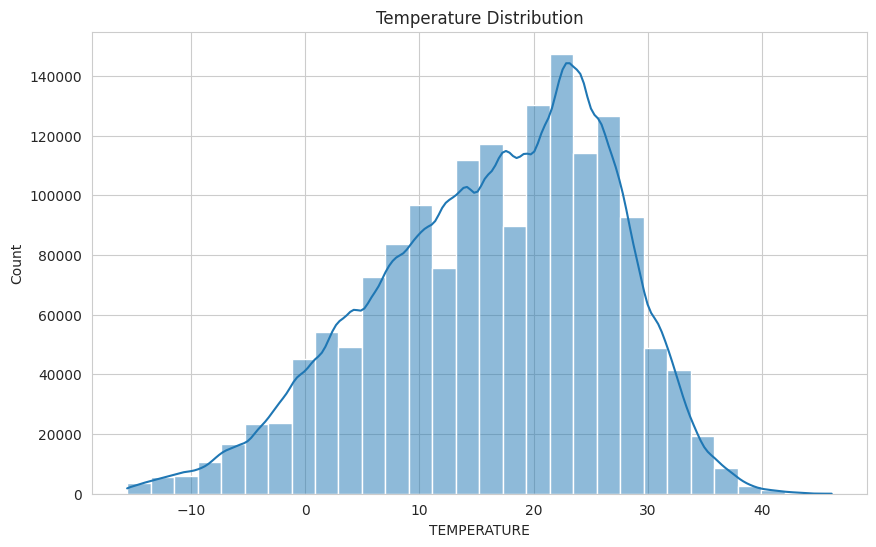

In [38]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['TEMPERATURE'],
    bins=30,
    kde=True
)

plt.title("Temperature Distribution")

plt.show()

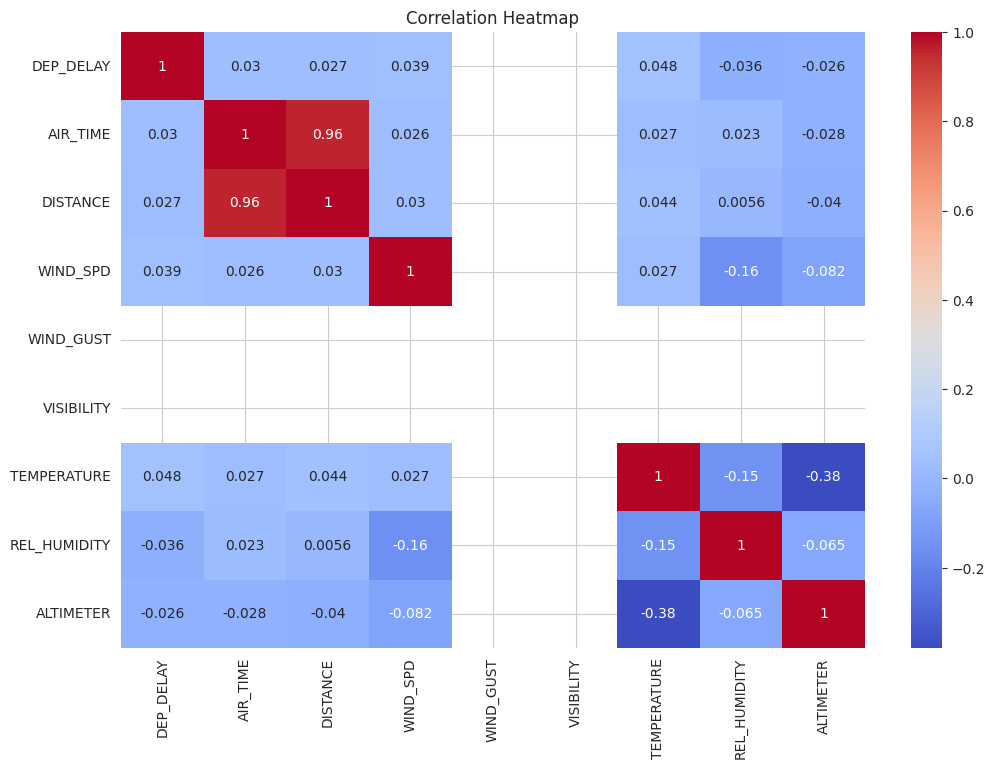

In [39]:
numeric_cols = [
    'DEP_DELAY',
    'AIR_TIME',
    'DISTANCE',
    'WIND_SPD',
    'WIND_GUST',
    'VISIBILITY',
    'TEMPERATURE',
    'REL_HUMIDITY',
    'ALTIMETER'
]

plt.figure(figsize=(12,8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

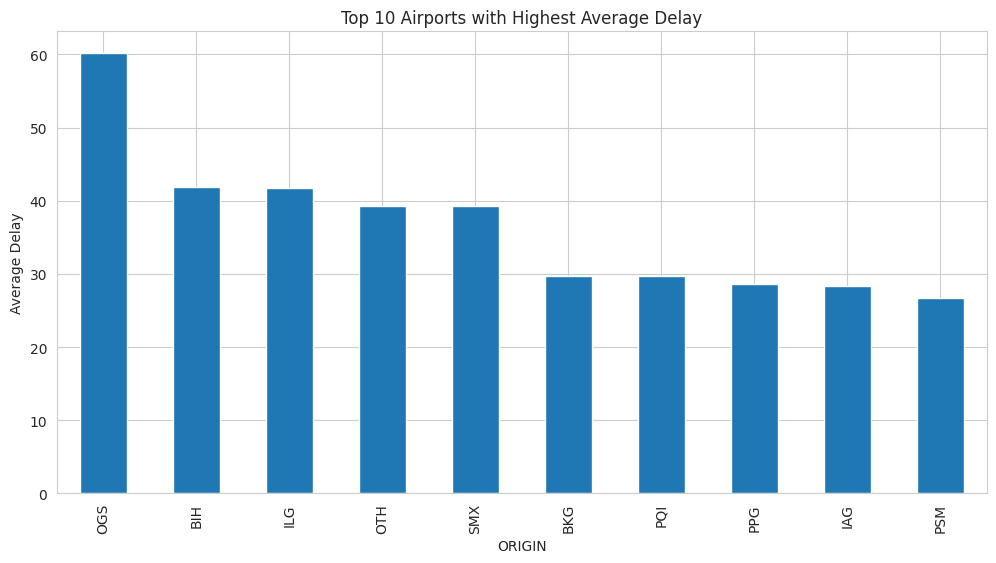

In [40]:
airport_delay = df.groupby('ORIGIN')['DEP_DELAY'].mean()

top10 = airport_delay.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

top10.plot(kind='bar')

plt.title("Top 10 Airports with Highest Average Delay")

plt.ylabel("Average Delay")

plt.show()

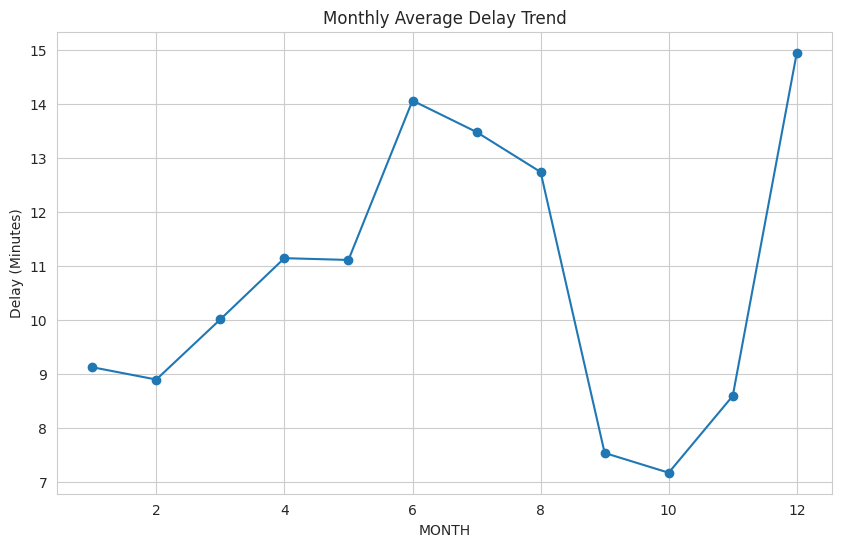

In [41]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

df['MONTH'] = df['FL_DATE'].dt.month

monthly_delay = df.groupby('MONTH')['DEP_DELAY'].mean()

plt.figure(figsize=(10,6))

monthly_delay.plot(marker='o')

plt.title("Monthly Average Delay Trend")

plt.ylabel("Delay (Minutes)")

plt.show()